# Zadanie 4

Celem kodu jest zbudowanie modelu predykcyjnego, który przewiduje zmienną `Avenue`, czyli wybór instrumentu inwestycyjnego, na podstawie zestawu dostępnych cech inwestora.



## 1. Import bibliotek

In [1]:
# Biblioteki do pracy z danymi i wizualizacji
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Biblioteki scikit-learn do przygotowania danych, treningu i ewaluacji
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Model XGBoost
from xgboost import XGBClassifier

## 2. Wczytanie danych

In [3]:
# Wczytanie pliku CSV
df = pd.read_csv('cleaned_finance_data (3).csv')

# Podgląd 
df.head()

,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source,nulls
0,Male,29,Yes,2.0,4.0,7.0,5.0,3.0,1.0,6.0,...,Monthly,20%-30%,Public Provident Fund,Health Care,Dividend,Fund Diversification,Assured Returns,Fixed Returns,Newspapers and Magazines,0
1,Male,28,Yes,2.0,3.0,6.0,5.0,1.0,4.0,7.0,...,Monthly,30%-40%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Television,0
2,Female,28,Yes,2.0,3.0,7.0,5.0,4.0,1.0,6.0,...,Daily,10%-20%,Mutual Fund,Health Care,Dividend,Better Returns,Assured Returns,Risk Free,Financial Consultants,0
3,Male,19,Yes,2.0,3.0,7.0,4.0,6.0,1.0,5.0,...,Weekly,10%-20%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Newspapers and Magazines,0
4,Male,32,Yes,2.0,4.0,7.0,5.0,3.0,1.0,6.0,...,Monthly,10%-20%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Fixed Returns,Financial Consultants,0


In [4]:
# Sprawdzenie rozmiaru datasetu i listy kolumn
print('Liczba wierszy i kolumn:', df.shape)
print('Kolumny:')
print(df.columns.tolist())

Liczba wierszy i kolumn: (9243, 25)
Kolumny:
['gender', 'age', 'Investment_Avenues', 'Mutual_Funds', 'Equity_Market', 'Debentures', 'Government_Bonds', 'Fixed_Deposits', 'PPF', 'Gold', 'Stock_Marktet', 'Factor', 'Objective', 'Purpose', 'Duration', 'Invest_Monitor', 'Expect', 'Avenue', 'What are your savings objectives?', 'Reason_Equity', 'Reason_Mutual', 'Reason_Bonds', 'Reason_FD', 'Source', 'nulls']


In [ ]:
## 3. Definicja zmiennej celu i cech wejściowych

Zmienną wyjaśnianą Y jest `Avenue`. Model ma przewidywać, który instrument inwestycyjny wybierze inwestor.



In [5]:
# Usuwamy wiersze, w których brakuje zmiennej docelowej
df = df.dropna(subset=['Avenue']).copy()

# LabelEncoder zamienia nazwy klas, np. 'Equity', na liczby 0, 1, 2...
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Avenue'])

# X zawiera wszystkie cechy poza targetem
X = df.drop(columns=['Avenue'])

# Podgląd mapowania klas
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
class_mapping

{'Equity': 0,
 'Fixed Deposits': 1,
 'Mutual Fund': 2,
 'Public Provident Fund': 3}

## 4. Podział kolumn na numeryczne i kategoryczne

In [6]:
# Kolumny tekstowe/kategoryczne
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Kolumny numeryczne
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print('Kolumny kategoryczne:', cat_cols)
print('Kolumny numeryczne:', num_cols)

Kolumny kategoryczne: ['gender', 'Investment_Avenues', 'Stock_Marktet', 'Factor', 'Objective', 'Purpose', 'Duration', 'Invest_Monitor', 'Expect', 'What are your savings objectives?', 'Reason_Equity', 'Reason_Mutual', 'Reason_Bonds', 'Reason_FD', 'Source']
Kolumny numeryczne: ['age', 'Mutual_Funds', 'Equity_Market', 'Debentures', 'Government_Bonds', 'Fixed_Deposits', 'PPF', 'Gold', 'nulls']


## 5. Preprocessing

Dane numeryczne uzupełniamy medianą, a dane kategoryczne najczęściej występującą wartością. Następnie zmienne kategoryczne kodujemy metodą One-Hot Encoding.

In [7]:
# Pipeline dla danych numerycznych
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Pipeline dla danych kategorycznych
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer stosuje inne operacje do kolumn numerycznych i kategorycznych
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

## 6. Budowa modelu XGBoost

XGBoost jest modelem dobrze działającym na danych tabelarycznych. Używamy go do klasyfikacji wieloklasowej, ponieważ `Avenue` ma kilka możliwych kategorii.

In [8]:
# Definicja modelu
xgb_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

# Pipeline łączy preprocessing i model w jeden spójny proces
model_b_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

## 7. Podział danych i trening modelu

In [9]:
# Podział danych na zbiór treningowy i testowy
# Stratify zachowuje podobny rozkład klas w train i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Trenowanie modelu
model_b_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 8. Ewaluacja modelu 

In [10]:
# Predykcja na zbiorze testowym
y_pred = model_b_pipeline.predict(X_test)

# Podstawowe metryki
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy Model B: {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'F1 macro Model B: {f1_macro:.4f}')
print(f'F1 weighted Model B: {f1_weighted:.4f}')

Accuracy Model B: 0.2023 (20.23%)
F1 macro Model B: 0.2016
F1 weighted Model B: 0.2018


In [11]:
# Raport klasyfikacji z nazwami klas
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

                       precision    recall  f1-score   support

               Equity       0.20      0.20      0.20       443
       Fixed Deposits       0.22      0.24      0.23       471
          Mutual Fund       0.21      0.20      0.20       475
Public Provident Fund       0.18      0.17      0.18       460

             accuracy                           0.20      1849
            macro avg       0.20      0.20      0.20      1849
         weighted avg       0.20      0.20      0.20      1849



In [12]:
# Macierz pomyłek jako DataFrame
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f'Actual: {c}' for c in label_encoder.classes_],
    columns=[f'Pred: {c}' for c in label_encoder.classes_]
)
cm_df

,Pred: Equity,Pred: Fixed Deposits,Pred: Mutual Fund,Pred: Public Provident Fund
Actual: Equity,87,123,127,106
Actual: Fixed Deposits,104,112,134,121
Actual: Mutual Fund,112,136,96,131
Actual: Public Provident Fund,134,137,110,79


## 9. Wykres ważności cech



In [13]:
# Pobranie nazw cech po preprocessingu
preprocessor_fitted = model_b_pipeline.named_steps['preprocessor']

# Nazwy cech numerycznych pozostają bez zmian
feature_names_num = num_cols

# Nazwy cech kategorycznych po OneHotEncoder
feature_names_cat = preprocessor_fitted.named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(cat_cols)

# Pełna lista nazw cech po transformacji
feature_names = list(feature_names_num) + list(feature_names_cat)

# Ważności cech z XGBoost
importances = model_b_pipeline.named_steps['model'].feature_importances_

# Tworzymy DataFrame z ważnościami
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df.head(20)

,feature,importance
16,Factor_Return,0.027996
36,What are your savings objectives?_Retirement Plan,0.027851
52,Reason_FD_Risk Free,0.027256
55,Source_Newspapers and Magazines,0.025381
21,Purpose_Returns,0.024318
19,Objective_Growth,0.024130
37,Reason_Equity_Capital Appreciation,0.023998
18,Objective_Capital Appreciation,0.023755
53,Source_Financial Consultants,0.023717
9,gender_Female,0.023237


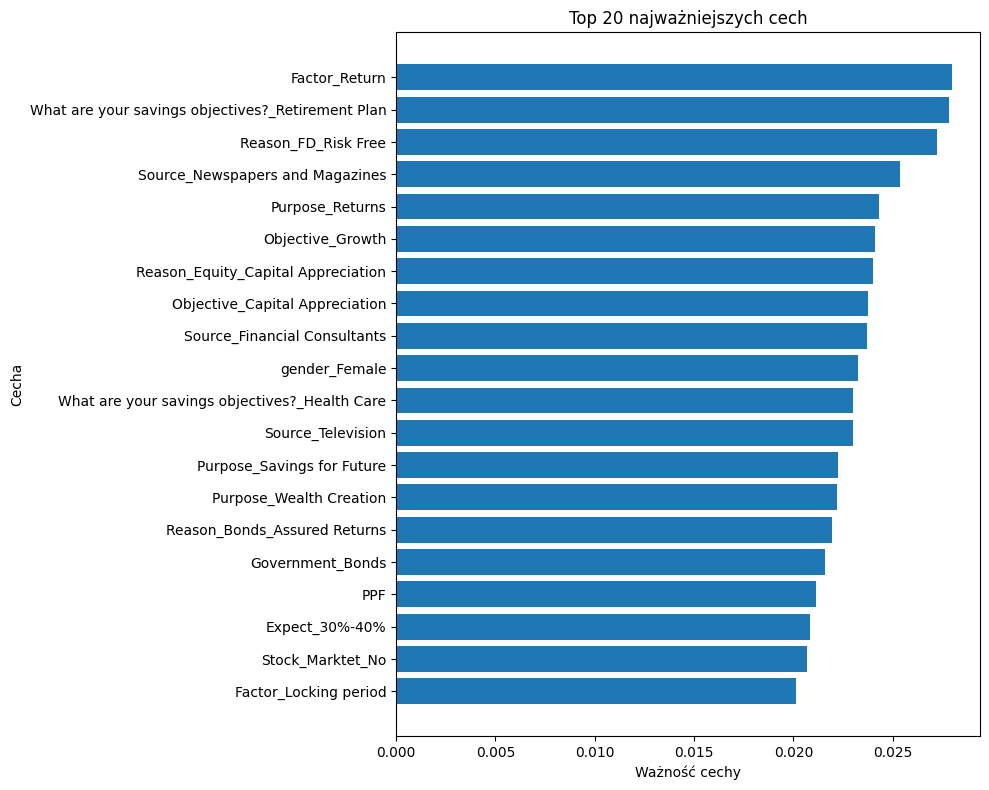

In [15]:
# Wykres TOP 20 najważniejszych cech
top_n = 20
top_features = importance_df.head(top_n).sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_features['feature'], top_features['importance'])
plt.title('Top 20 najważniejszych cech')
plt.xlabel('Ważność cechy')
plt.ylabel('Cecha')
plt.tight_layout()
plt.show()